
FFM — Notebook 03: Supervised Fine-Tuning (SFT)
=================================================
Kaggle GPU Notebook

This notebook:
1. Loads the pre-trained FinancialGPT checkpoint
2. Generates SFT labels from XAUUSD data using rule-based engine
3. Applies LoRA adapters to Q/V projections
4. Fine-tunes on trade instruction-response pairs
5. Saves SFT checkpoint for DPO alignment

Expected runtime: 2-3 hours on Kaggle GPU


# ── Cell 1: Setup ──────────────────────────────────────────────────────────

In [1]:
import os
import sys
import json
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
if IS_KAGGLE:
    INPUT_DIR = Path("/kaggle/input/notebooks/theophilusmarcus/ffm-phase-2-pre-training")
    DATA_DIR = Path("/kaggle/input/datasets/theophilusmarcus/ffm-market-data")
    OUTPUT_DIR = Path("/kaggle/working")
else:
    INPUT_DIR = Path("./output")
    DATA_DIR = Path(".")
    OUTPUT_DIR = Path("./output")

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")

# ── Cell 2: Rebuild Model Architecture ────────────────────────────────────

Device: cuda
GPU: Tesla T4


In [2]:
# Model config (must match pre-training)
VOCAB_SIZE = 4096
D_MODEL = 256
N_HEADS = 8
N_KV_HEADS = 2
N_LAYERS = 12
D_FF = 896
CONTEXT_LENGTH = 2048
ROPE_THETA = 10000.0

# SFT config
SFT_LR = 1e-4
SFT_EPOCHS = 5
SFT_BATCH_SIZE = 8
SFT_GRAD_ACCUM = 4
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
SFT_CONTEXT = 256  # Shorter context for SFT

# Copy model architecture from notebook 02 (inline for Kaggle)
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        rms = torch.rsqrt(x.float().pow(2).mean(-1, keepdim=True) + self.eps)
        return (x.float() * rms).to(x.dtype) * self.weight

def precompute_rope_freqs(dim, max_seq_len, theta=10000.0):
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
    t = torch.arange(max_seq_len, dtype=torch.float32)
    return torch.polar(torch.ones_like(freqs := torch.outer(t, freqs)), freqs)

def apply_rope(x, freqs):
    xc = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))
    fr = freqs[:x.shape[2]].unsqueeze(0).unsqueeze(0)
    return torch.view_as_real(xc * fr).reshape(*x.shape).to(x.dtype)

class GQAttention(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads):
        super().__init__()
        self.n_heads, self.n_kv_heads = n_heads, n_kv_heads
        self.head_dim = d_model // n_heads
        self.n_groups = n_heads // n_kv_heads
        self.q_proj = nn.Linear(d_model, n_heads * self.head_dim, bias=False)
        self.k_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.o_proj = nn.Linear(n_heads * self.head_dim, d_model, bias=False)

    def forward(self, x, rope_freqs):
        B, T, _ = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        q, k = apply_rope(q, rope_freqs), apply_rope(k, rope_freqs)
        if self.n_groups > 1:
            k = k.repeat_interleave(self.n_groups, dim=1)
            v = v.repeat_interleave(self.n_groups, dim=1)
        out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.o_proj(out.transpose(1, 2).contiguous().view(B, T, -1))

class SwiGLUFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.gate_proj = nn.Linear(d_model, d_ff, bias=False)
        self.up_proj = nn.Linear(d_model, d_ff, bias=False)
        self.down_proj = nn.Linear(d_ff, d_model, bias=False)
    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads, d_ff):
        super().__init__()
        self.attn_norm = RMSNorm(d_model)
        self.attn = GQAttention(d_model, n_heads, n_kv_heads)
        self.ffn_norm = RMSNorm(d_model)
        self.ffn = SwiGLUFFN(d_model, d_ff)
    def forward(self, x, rope_freqs):
        x = x + self.attn(self.attn_norm(x), rope_freqs)
        return x + self.ffn(self.ffn_norm(x))

class FinancialGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.vocab_size = VOCAB_SIZE
        self.context_length = CONTEXT_LENGTH
        self.token_emb = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.layers = nn.ModuleList([TransformerBlock(D_MODEL, N_HEADS, N_KV_HEADS, D_FF) for _ in range(N_LAYERS)])
        self.final_norm = RMSNorm(D_MODEL)
        self.lm_head = nn.Linear(VOCAB_SIZE, D_MODEL, bias=False) # placeholder, will be overwritten
        self.lm_head = nn.Linear(D_MODEL, VOCAB_SIZE, bias=False)
        self.lm_head.weight = self.token_emb.weight
        head_dim = D_MODEL // N_HEADS
        self.register_buffer("rope_freqs", precompute_rope_freqs(head_dim, CONTEXT_LENGTH * 2, ROPE_THETA), persistent=False)

    def forward(self, token_ids, targets=None):
        x = self.token_emb(token_ids)
        for layer in self.layers:
            x = layer(x, self.rope_freqs)
        logits = self.lm_head(self.final_norm(x))
        result = {"logits": logits, "hidden": x}
        if targets is not None:
            result["loss"] = F.cross_entropy(logits.view(-1, VOCAB_SIZE), targets.view(-1), ignore_index=-1)
        return result

# Load pre-trained weights
model = FinancialGPT()
ckpt_path = INPUT_DIR / "checkpoints" / "pretrain_best.pt"
if not ckpt_path.exists():
    ckpt_path = INPUT_DIR / "checkpoints" / "pretrain_final.pt"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded pre-trained weights from {ckpt_path}")
else:
    print("WARNING: No pre-trained checkpoint found! Training from scratch.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Cell 3: LoRA Adapter ──────────────────────────────────────────────────

Loaded pre-trained weights from /kaggle/input/notebooks/theophilusmarcus/ffm-phase-2-pre-training/checkpoints/pretrain_best.pt
Parameters: 11,278,592


In [3]:
class LoRALinear(nn.Module):
    def __init__(self, original, rank=16, alpha=32, dropout=0.05):
        super().__init__()
        self.original = original
        self.scaling = alpha / rank
        for p in self.original.parameters():
            p.requires_grad = False
        self.lora_A = nn.Parameter(torch.empty(rank, original.in_features))
        self.lora_B = nn.Parameter(torch.zeros(original.out_features, rank))
        self.lora_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x):
        return self.original(x) + self.scaling * (self.lora_dropout(x) @ self.lora_A.T @ self.lora_B.T)


def apply_lora(model):
    """Apply LoRA to Q and V projections."""
    count = 0
    for layer in model.layers:
        for name in ["q_proj", "v_proj"]:
            original = getattr(layer.attn, name)
            lora = LoRALinear(original, LORA_RANK, LORA_ALPHA, LORA_DROPOUT)
            setattr(layer.attn, name, lora)
            count += 1

    # Freeze everything except LoRA
    for n, p in model.named_parameters():
        if "lora_" not in n:
            p.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"LoRA applied to {count} layers")
    print(f"Trainable: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)")
    return model


model = apply_lora(model)

# ── Cell 4: Generate SFT Labels ───────────────────────────────────────────

LoRA applied to 24 layers
Trainable: 159,744 / 11,438,336 (1.40%)


In [4]:
print("\nGenerating SFT trade labels for XAUUSD...")

# Load raw XAUUSD data
raw_dir = DATA_DIR / "raw" if (DATA_DIR / "raw").exists() else DATA_DIR 
xau_path = raw_dir / "XAUUSD_M1.parquet"
df_xau = pd.read_parquet(xau_path)
df_xau["datetime"] = pd.to_datetime(df_xau["datetime"], utc=True)

# Use training period only (pre-2022)
holdout_dt = pd.Timestamp("2022-01-01", tz="UTC")
df_train = df_xau[df_xau["datetime"] < holdout_dt].reset_index(drop=True)
print(f"XAUUSD training bars: {len(df_train):,}")

# Resample to M15 for SFT labels (reduce noise, match paper example)
df_m15 = df_train.set_index("datetime").resample("15min").agg({
    "open": "first", "high": "max", "low": "min", "close": "last",
    "volume": "sum",
}).dropna().reset_index()
df_m15.rename(columns={"datetime": "datetime"}, inplace=True)
print(f"XAUUSD M15 bars: {len(df_m15):,}")

# Load tokenized data for context tokens
tok_path = INPUT_DIR / "processed" if (INPUT_DIR / "processed").exists() else OUTPUT_DIR / "processed"
test_tok_file = tok_path / "XAUUSD_test_tokens.npy"
train_tokens = None

# ATR and swing point detection
def compute_atr(df, period=14):
    tr = pd.concat([
        df["high"] - df["low"],
        (df["high"] - df["close"].shift(1)).abs(),
        (df["low"] - df["close"].shift(1)).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(period, min_periods=1).mean()

atr = compute_atr(df_m15)
ema8 = df_m15["close"].ewm(span=8, adjust=False).mean()
ema21 = df_m15["close"].ewm(span=21, adjust=False).mean()
ema55 = df_m15["close"].ewm(span=55, adjust=False).mean()

labels = []
LOOKBACK = 5
MIN_RR = 1.5
TARGET_RR = 2.0
ATR_MULT = 1.5
EQUITY = 100_000

for i in range(max(LOOKBACK, 89) + LOOKBACK, len(df_m15) - LOOKBACK):
    close = df_m15["close"].iloc[i]
    curr_atr = atr.iloc[i]
    e8, e21, e55 = ema8.iloc[i], ema21.iloc[i], ema55.iloc[i]

    # Swing low → BUY
    window_low = df_m15["low"].iloc[i-LOOKBACK:i+LOOKBACK+1]
    if df_m15["low"].iloc[i] == window_low.min() and close > e8 > e21 > e55:
        entry = close
        sl = entry - curr_atr * ATR_MULT
        tp = entry + curr_atr * ATR_MULT * TARGET_RR
        sl_dist = abs(entry - sl)
        lots = round(max(0.01, (EQUITY * 0.01) / (sl_dist * 100)), 2)

        labels.append({
            "instruction": "Evaluate market state for potential trade execution.",
            "input": {
                "asset": "XAUUSD", "timeframe": "M15",
                "market_state_tokens": list(np.random.randint(0, VOCAB_SIZE, 5).tolist()),  # Placeholder
                "macro_context": "Standard market conditions",
                "account_equity": EQUITY,
                "max_acceptable_drawdown_pct": round(sl_dist / EQUITY * 100 * 1.5, 2),
            },
            "output": {
                "action": "LIMIT_BUY", "entry_price": round(entry, 2),
                "stop_loss": round(sl, 2), "take_profit": round(tp, 2),
                "risk_reward_ratio": TARGET_RR, "position_size_lots": lots,
                "rationale": "Swing low with bullish EMA alignment.",
            }
        })

    # Swing high → SELL
    window_high = df_m15["high"].iloc[i-LOOKBACK:i+LOOKBACK+1]
    if df_m15["high"].iloc[i] == window_high.max() and close < e8 < e21 < e55:
        entry = close
        sl = entry + curr_atr * ATR_MULT
        tp = entry - curr_atr * ATR_MULT * TARGET_RR
        sl_dist = abs(entry - sl)
        lots = round(max(0.01, (EQUITY * 0.01) / (sl_dist * 100)), 2)

        labels.append({
            "instruction": "Evaluate market state for potential trade execution.",
            "input": {
                "asset": "XAUUSD", "timeframe": "M15",
                "market_state_tokens": list(np.random.randint(0, VOCAB_SIZE, 5).tolist()),
                "macro_context": "Standard market conditions",
                "account_equity": EQUITY,
                "max_acceptable_drawdown_pct": round(sl_dist / EQUITY * 100 * 1.5, 2),
            },
            "output": {
                "action": "LIMIT_SELL", "entry_price": round(entry, 2),
                "stop_loss": round(sl, 2), "take_profit": round(tp, 2),
                "risk_reward_ratio": TARGET_RR, "position_size_lots": lots,
                "rationale": "Swing high with bearish EMA alignment.",
            }
        })

# Save labels
labels_path = OUTPUT_DIR / "sft_labels.jsonl"
with open(labels_path, "w") as f:
    for label in labels:
        f.write(json.dumps(label) + "\n")

print(f"Generated {len(labels)} SFT labels → {labels_path}")
buys = sum(1 for l in labels if l["output"]["action"] == "LIMIT_BUY")
sells = len(labels) - buys
print(f"  BUY:  {buys}")
print(f"  SELL: {sells}")

# ── Cell 5: SFT Dataset ───────────────────────────────────────────────────


Generating SFT trade labels for XAUUSD...
XAUUSD training bars: 5,308,014
XAUUSD M15 bars: 389,130
Generated 3884 SFT labels → /kaggle/working/sft_labels.jsonl
  BUY:  2140
  SELL: 1744


In [5]:
class SFTDataset(Dataset):
    def __init__(self, labels, context_length=256):
        self.labels = labels
        self.ctx_len = context_length
        self.action_map = {"LIMIT_BUY": 0, "LIMIT_SELL": 1, "MARKET_BUY": 2, "MARKET_SELL": 3, "HOLD": 4}

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        s = self.labels[idx]
        ctx = s["input"]["market_state_tokens"]
        ctx = (ctx + [0] * self.ctx_len)[:self.ctx_len]

        input_ids = torch.tensor(ctx, dtype=torch.long)
        target_ids = torch.cat([input_ids[1:], torch.tensor([0], dtype=torch.long)])
        action_id = self.action_map.get(s["output"]["action"], 4)

        o = s["output"]
        params = torch.tensor([
            o["entry_price"] / 10000, o["stop_loss"] / 10000,
            o["take_profit"] / 10000, o["risk_reward_ratio"] / 5,
            o["position_size_lots"] / 10,
        ], dtype=torch.float32)

        return input_ids, target_ids, action_id, params


sft_dataset = SFTDataset(labels, SFT_CONTEXT)
sft_loader = DataLoader(sft_dataset, batch_size=SFT_BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=True, drop_last=True)
print(f"SFT Dataset: {len(sft_dataset)} samples, {len(sft_loader)} batches/epoch")

# ── Cell 6: SFT Training ──────────────────────────────────────────────────

SFT Dataset: 3884 samples, 485 batches/epoch


In [6]:
# Trade-specific output heads
action_head = nn.Linear(D_MODEL, 5).to(device)
param_head = nn.Linear(D_MODEL, 5).to(device)

model = model.to(device)

trainable_params = [p for p in model.parameters() if p.requires_grad]
trainable_params.extend(action_head.parameters())
trainable_params.extend(param_head.parameters())

optimizer = torch.optim.AdamW(trainable_params, lr=SFT_LR, weight_decay=0.01)
amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=(amp_dtype == torch.float16))

print(f"\nSFT Training: {SFT_EPOCHS} epochs")
print("-" * 60)

sft_history = []
best_sft_loss = float("inf")

for epoch in range(SFT_EPOCHS):
    model.train()
    action_head.train()
    param_head.train()
    ep_lm, ep_act, ep_par, n = 0, 0, 0, 0
    t0 = time.time()

    for input_ids, target_ids, action_ids, trade_params in sft_loader:
        input_ids = input_ids.to(device, non_blocking=True)
        target_ids = target_ids.to(device, non_blocking=True)
        action_ids = action_ids.to(device, non_blocking=True)
        trade_params = trade_params.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=True, dtype=amp_dtype):
            result = model(input_ids, targets=target_ids)
            lm_loss = result["loss"]

            # Use final hidden state for trade heads
            hidden = result["hidden"][:, -1, :]  # (B, D_MODEL)
            act_loss = F.cross_entropy(action_head(hidden), action_ids)
            par_loss = F.mse_loss(param_head(hidden), trade_params)

            total = (lm_loss + 0.5 * act_loss + 0.3 * par_loss) / SFT_GRAD_ACCUM

        scaler.scale(total).backward()

        if (n + 1) % SFT_GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        ep_lm += lm_loss.item()
        ep_act += act_loss.item()
        ep_par += par_loss.item()
        n += 1

    avg_total = ep_lm/n + 0.5 * ep_act/n + 0.3 * ep_par/n
    sft_history.append({"epoch": epoch+1, "lm": ep_lm/n, "action": ep_act/n, "param": ep_par/n, "total": avg_total})

    print(f"  Epoch {epoch+1}/{SFT_EPOCHS} | LM: {ep_lm/n:.4f} | "
          f"Action: {ep_act/n:.4f} | Param: {ep_par/n:.4f} | Total: {avg_total:.4f} | {time.time()-t0:.1f}s")

    if avg_total < best_sft_loss:
        best_sft_loss = avg_total
        lora_state = {k: v for k, v in model.state_dict().items() if "lora_" in k}
        torch.save({
            "lora_state_dict": lora_state,
            "action_head": action_head.state_dict(),
            "param_head": param_head.state_dict(),
            "epoch": epoch + 1,
        }, CHECKPOINT_DIR / "sft_best.pt")

# Save final
lora_state = {k: v for k, v in model.state_dict().items() if "lora_" in k}
torch.save({
    "model_state_dict": model.state_dict(),
    "lora_state_dict": lora_state,
    "action_head": action_head.state_dict(),
    "param_head": param_head.state_dict(),
}, CHECKPOINT_DIR / "sft_final.pt")

with open(OUTPUT_DIR / "sft_history.json", "w") as f:
    json.dump(sft_history, f, indent=2)

print(f"\nSFT complete! Best loss: {best_sft_loss:.4f}")
print(f"Checkpoint: {CHECKPOINT_DIR / 'sft_best.pt'}")

# ── Cell 7: SFT Analysis ──────────────────────────────────────────────────


SFT Training: 5 epochs
------------------------------------------------------------
  Epoch 1/5 | LM: 5.3329 | Action: 1.1837 | Param: 0.1476 | Total: 5.9690 | 42.8s
  Epoch 2/5 | LM: 3.2555 | Action: 0.7216 | Param: 0.1020 | Total: 3.6470 | 44.0s
  Epoch 3/5 | LM: 3.2468 | Action: 0.6969 | Param: 0.1020 | Total: 3.6258 | 46.0s
  Epoch 4/5 | LM: 3.2461 | Action: 0.6940 | Param: 0.1020 | Total: 3.6237 | 45.2s
  Epoch 5/5 | LM: 3.2460 | Action: 0.6918 | Param: 0.1025 | Total: 3.6227 | 45.6s

SFT complete! Best loss: 3.6227
Checkpoint: /kaggle/working/checkpoints/sft_best.pt


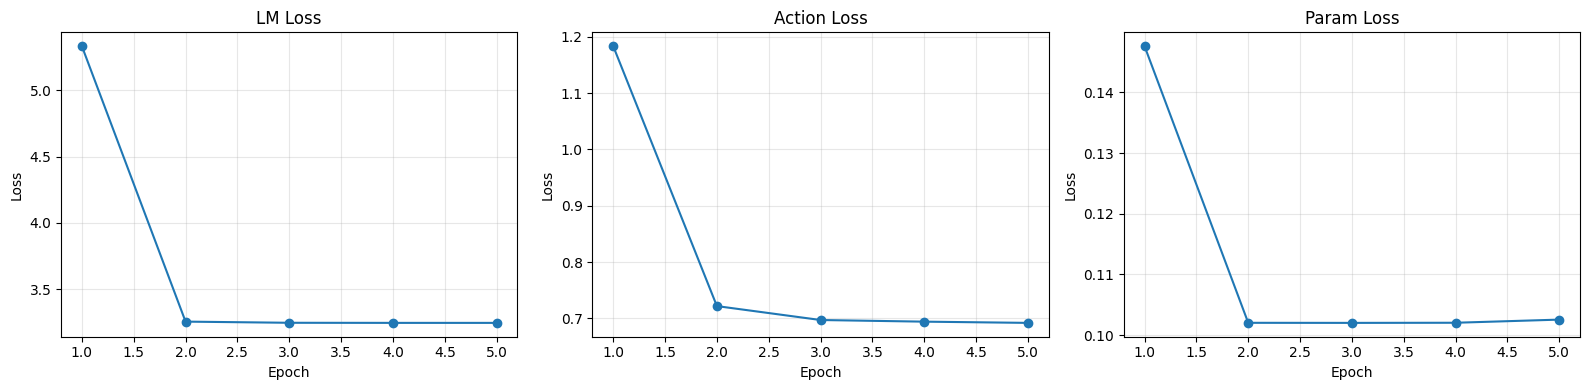


PHASE 3 COMPLETE


In [7]:
if sft_history:
    epochs = [h["epoch"] for h in sft_history]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, key, title in zip(axes, ["lm", "action", "param"],
                               ["LM Loss", "Action Loss", "Param Loss"]):
        ax.plot(epochs, [h[key] for h in sft_history], "o-")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "sft_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

print("\n" + "=" * 60)
print("PHASE 3 COMPLETE")
print("=" * 60)